In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Telco customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove missing TotalCharges
data = data.dropna(subset=["TotalCharges"]).copy()

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

display(data.head())

Dataset loaded successfully!
Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Calculate key customer KPIs

total_customers = len(data)

churned_customers = (data["Churn"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

average_monthly_charges = data["MonthlyCharges"].mean()

total_revenue = data["MonthlyCharges"].sum()

print("CUSTOMER KPI METRICS")
print("=" * 50)
print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Average Monthly Charges: ${average_monthly_charges:.2f}")
print(f"Total Monthly Charges: ${total_revenue:,.2f}")

CUSTOMER KPI METRICS
Total Customers: 7,032
Churned Customers: 1,869
Churn Rate: 26.58%
Average Monthly Charges: $64.80
Total Monthly Charges: $455,661.00


In [4]:
# Create KPI summary table

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Average Monthly Charges ($)",
        "Total Monthly Charges ($)"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(average_monthly_charges, 2),
        round(total_revenue, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Customers,7032.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.58
3,Average Monthly Charges ($),64.80
4,Total Monthly Charges ($),455661.00


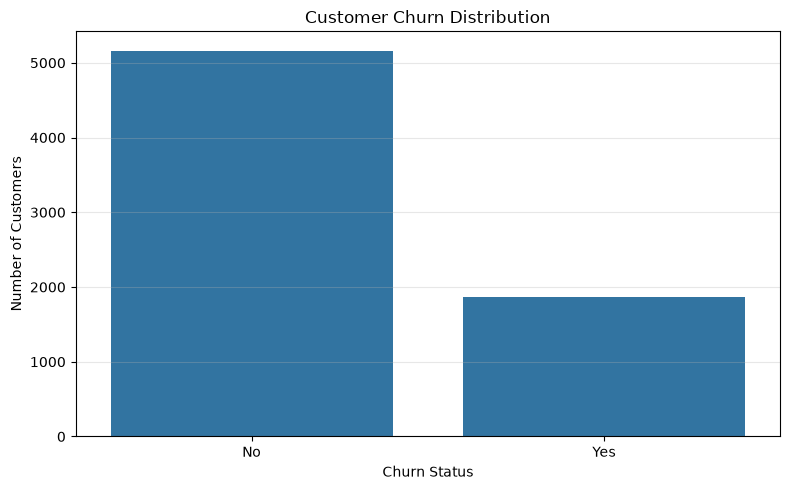

In [5]:
# Churn distribution

churn_counts = data["Churn"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Create simple customer segments based on tenure

data["CustomerSegment"] = pd.cut(
    data["tenure"],
    bins=[-1, 12, 36, 100],
    labels=["New Customers", "Growing Customers", "Loyal Customers"]
)

print("Customer segments created!")
display(data["CustomerSegment"].value_counts().to_frame("Customer Count"))

Customer segments created!


,Customer Count
CustomerSegment,
Loyal Customers,3001
New Customers,2175
Growing Customers,1856


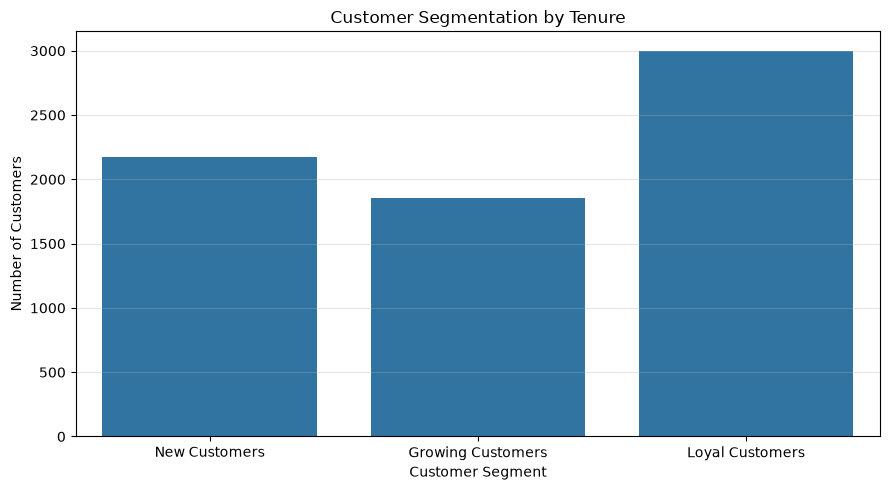

In [7]:
# Customer segmentation chart

segment_counts = data["CustomerSegment"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segmentation by Tenure")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Churn rate by customer segment

segment_churn = (
    data.groupby("CustomerSegment", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="Churn Rate (%)")
)

print("Churn Rate by Customer Segment")
print("=" * 50)

display(segment_churn)

Churn Rate by Customer Segment


,CustomerSegment,Churn Rate (%)
0,New Customers,47.68
1,Growing Customers,25.54
2,Loyal Customers,11.93


In [9]:
# Create Business Intelligence Dashboard

fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "Customer Analytics Dashboard",
    fontsize=20,
    fontweight="bold"
)

print("Dashboard layout created!")

Dashboard layout created!


<Figure size 1600x1000 with 0 Axes>

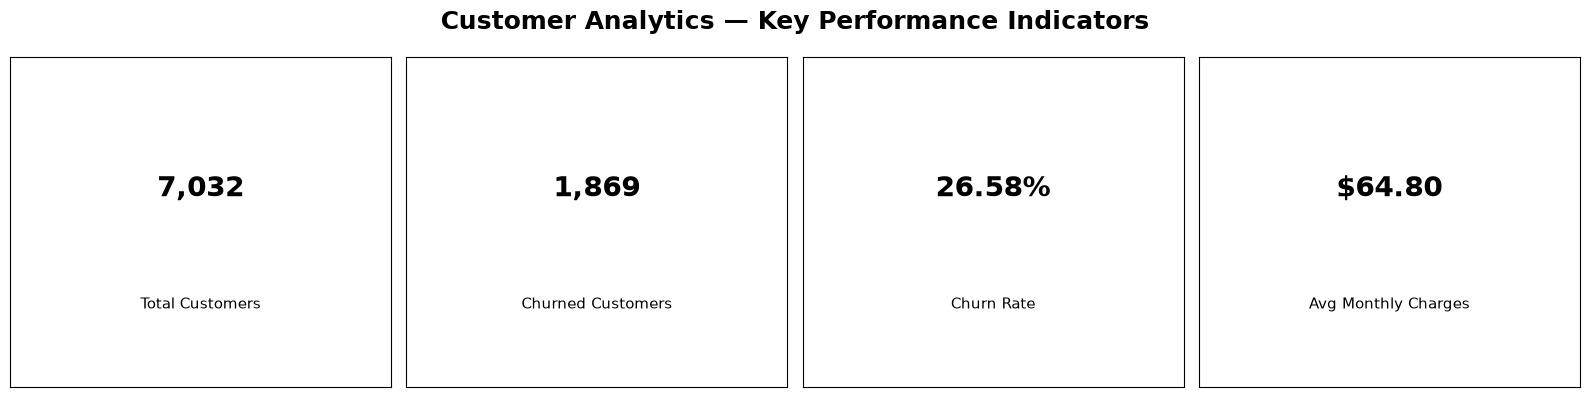

In [10]:
# Create KPI cards

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kpis = [
    ("Total Customers", f"{total_customers:,}"),
    ("Churned Customers", f"{churned_customers:,}"),
    ("Churn Rate", f"{churn_rate:.2f}%"),
    ("Avg Monthly Charges", f"${average_monthly_charges:.2f}")
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.6, value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )
    
    ax.text(
        0.5, 0.25, title,
        ha="center",
        va="center",
        fontsize=11
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(True)

plt.suptitle(
    "Customer Analytics — Key Performance Indicators",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

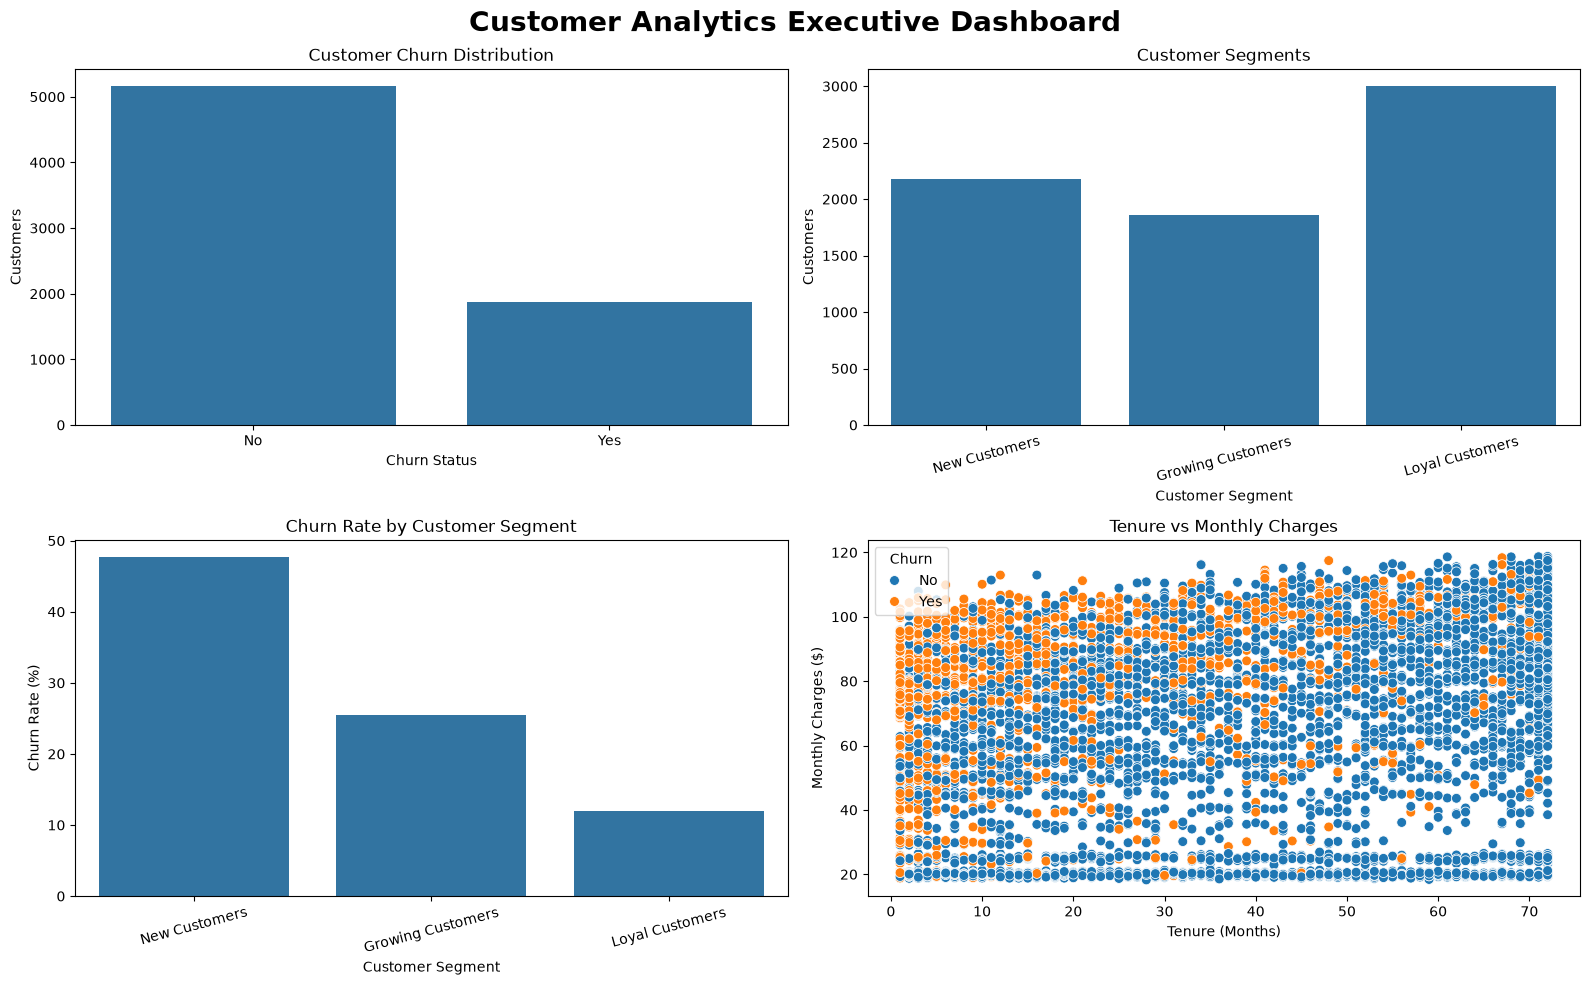

In [11]:
# Create executive dashboard with KPIs and business charts

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1: Churn distribution
churn_counts = data["Churn"].value_counts()

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xlabel("Churn Status")
axes[0, 0].set_ylabel("Customers")

# Chart 2: Customer segments
segment_counts = data["CustomerSegment"].value_counts()

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Customer Segments")
axes[0, 1].set_xlabel("Customer Segment")
axes[0, 1].set_ylabel("Customers")
axes[0, 1].tick_params(axis="x", rotation=15)

# Chart 3: Churn rate by segment
sns.barplot(
    data=segment_churn,
    x="CustomerSegment",
    y="Churn Rate (%)",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Churn Rate by Customer Segment")
axes[1, 0].set_xlabel("Customer Segment")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=15)

# Chart 4: Tenure vs Monthly Charges
sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    ax=axes[1, 1],
    s=50
)

axes[1, 1].set_title("Tenure vs Monthly Charges")
axes[1, 1].set_xlabel("Tenure (Months)")
axes[1, 1].set_ylabel("Monthly Charges ($)")

plt.suptitle(
    "Customer Analytics Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

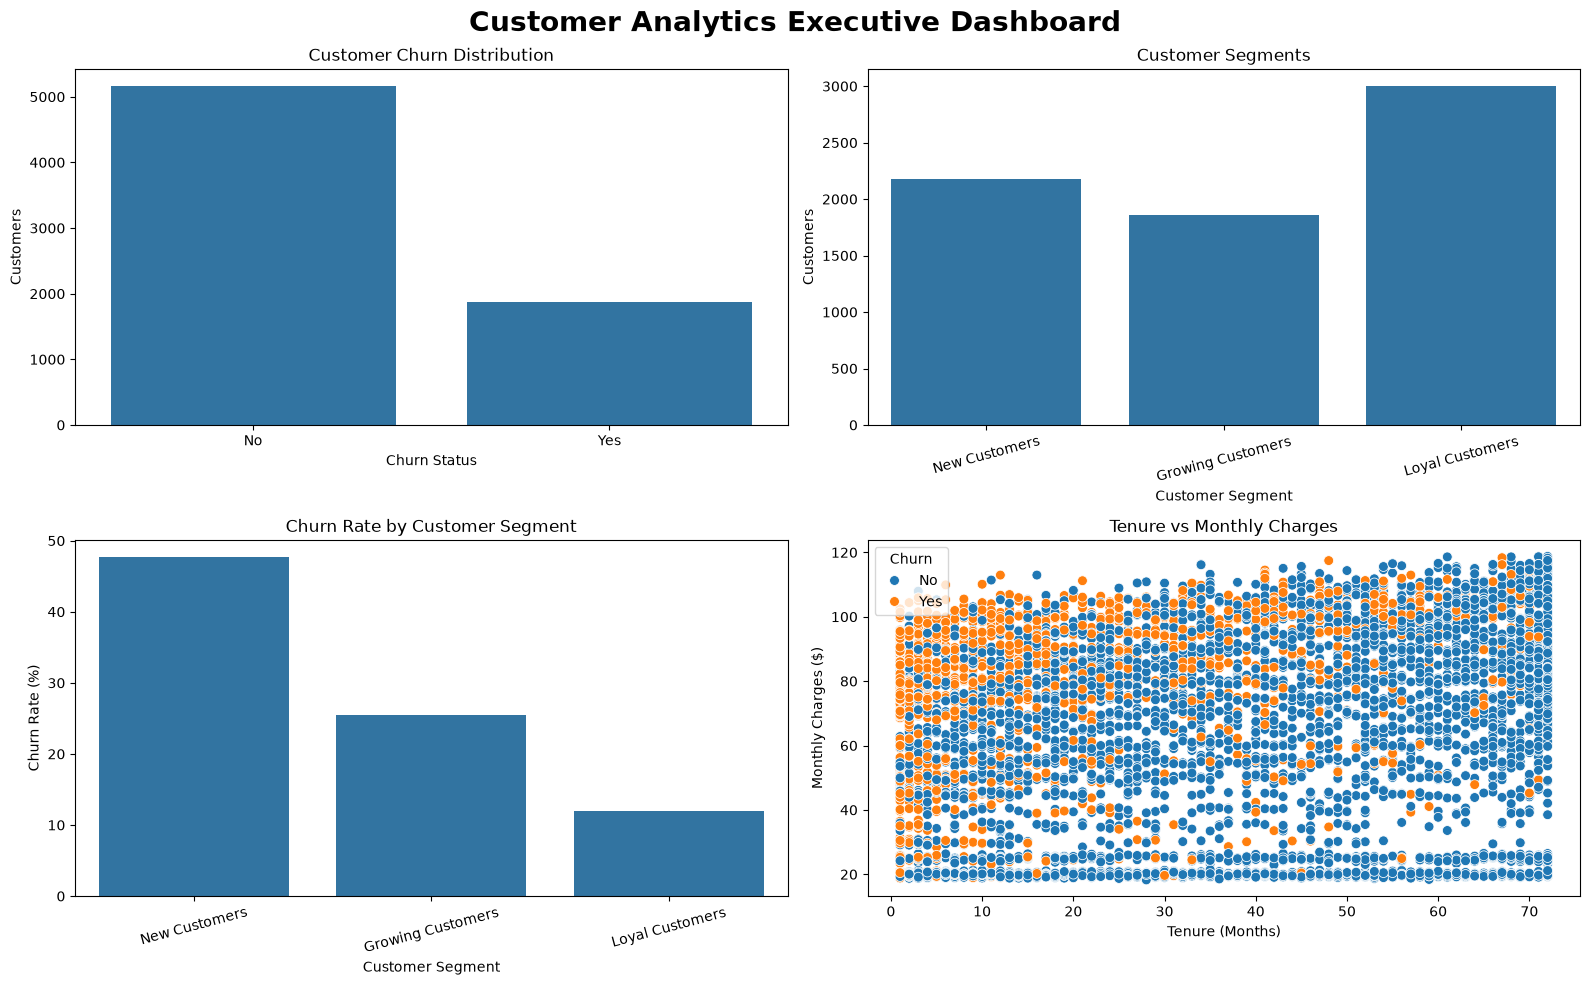

Dashboard saved successfully!


In [12]:
# Save executive dashboard as an image

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Churn distribution
churn_counts = data["Churn"].value_counts()
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0, 0])
axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xlabel("Churn Status")
axes[0, 0].set_ylabel("Customers")

# Customer segments
segment_counts = data["CustomerSegment"].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=axes[0, 1])
axes[0, 1].set_title("Customer Segments")
axes[0, 1].set_xlabel("Customer Segment")
axes[0, 1].set_ylabel("Customers")
axes[0, 1].tick_params(axis="x", rotation=15)

# Churn rate by segment
sns.barplot(
    data=segment_churn,
    x="CustomerSegment",
    y="Churn Rate (%)",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn Rate by Customer Segment")
axes[1, 0].set_xlabel("Customer Segment")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=15)

# Tenure vs charges
sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    ax=axes[1, 1],
    s=50
)
axes[1, 1].set_title("Tenure vs Monthly Charges")
axes[1, 1].set_xlabel("Tenure (Months)")
axes[1, 1].set_ylabel("Monthly Charges ($)")

plt.suptitle(
    "Customer Analytics Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "executive_customer_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Dashboard saved successfully!")

In [13]:
# Create business insight summary

business_insights = [
    f"The dataset contains {total_customers:,} customers.",
    f"{churned_customers:,} customers are recorded as churned.",
    f"The overall churn rate is {churn_rate:.2f}%.",
    f"Average monthly charges are ${average_monthly_charges:.2f}.",
    "Customer segments based on tenure provide a simple view of customer lifecycle stages.",
    "Churn rates by segment can help decision-makers identify groups that may require additional retention attention.",
    "The dashboard combines customer volume, churn, segmentation, spending, and tenure into one executive view."
]

print("BUSINESS INSIGHT SUMMARY")
print("=" * 60)

for i, insight in enumerate(business_insights, 1):
    print(f"{i}. {insight}")

BUSINESS INSIGHT SUMMARY
1. The dataset contains 7,032 customers.
2. 1,869 customers are recorded as churned.
3. The overall churn rate is 26.58%.
4. Average monthly charges are $64.80.
5. Customer segments based on tenure provide a simple view of customer lifecycle stages.
6. Churn rates by segment can help decision-makers identify groups that may require additional retention attention.
7. The dashboard combines customer volume, churn, segmentation, spending, and tenure into one executive view.


In [14]:
# Save business insights

with open("dashboard_business_insights.txt", "w") as file:
    file.write("BUSINESS INSIGHT SUMMARY - DAY 34\n")
    file.write("=" * 60 + "\n\n")

    for i, insight in enumerate(business_insights, 1):
        file.write(f"{i}. {insight}\n")

print("Business insight report saved successfully!")

Business insight report saved successfully!


In [15]:
# Document dashboard storytelling decisions

storytelling_decisions = [
    "KPI cards were placed at the top to provide an immediate executive overview.",
    "Churn distribution was included to show the overall customer retention picture.",
    "Customer segmentation was included to show the distribution of customers across lifecycle stages.",
    "Churn rate by segment was included to help identify groups requiring retention attention.",
    "Tenure versus MonthlyCharges was included to connect customer relationship duration with spending.",
    "The dashboard uses simple charts and clear labels so that business users can interpret the information quickly."
]

print("DASHBOARD STORYTELLING DECISIONS")
print("=" * 60)

for i, decision in enumerate(storytelling_decisions, 1):
    print(f"{i}. {decision}")

DASHBOARD STORYTELLING DECISIONS
1. KPI cards were placed at the top to provide an immediate executive overview.
2. Churn distribution was included to show the overall customer retention picture.
3. Customer segmentation was included to show the distribution of customers across lifecycle stages.
4. Churn rate by segment was included to help identify groups requiring retention attention.
5. Tenure versus MonthlyCharges was included to connect customer relationship duration with spending.
6. The dashboard uses simple charts and clear labels so that business users can interpret the information quickly.


In [16]:
# Save dashboard storytelling decisions

with open("dashboard_storytelling_decisions.txt", "w") as file:
    file.write("DASHBOARD STORYTELLING DECISIONS - DAY 34\n")
    file.write("=" * 60 + "\n\n")

    for i, decision in enumerate(storytelling_decisions, 1):
        file.write(f"{i}. {decision}\n")

print("Storytelling report saved successfully!")

Storytelling report saved successfully!


In [17]:
# Check Day 34 output files

import os

day34_files = [
    "business_intelligence_dashboard.ipynb",
    "executive_customer_dashboard.png",
    "dashboard_business_insights.txt",
    "dashboard_storytelling_decisions.txt"
]

print("DAY 34 OUTPUT FILES")
print("=" * 50)

for file in day34_files:
    if os.path.exists(file):
        print(f"✓ Found: {file}")
    else:
        print(f"✗ Missing: {file}")

DAY 34 OUTPUT FILES
✓ Found: business_intelligence_dashboard.ipynb
✓ Found: executive_customer_dashboard.png
✓ Found: dashboard_business_insights.txt
✓ Found: dashboard_storytelling_decisions.txt
